# Formative 2: Multimodal Data Preprocessing
## User Identity and Product Recommendation System

**Group Members:** Winston (Member 1), Miracle (Member 2), Mahe (Member 3)

**Institution:** African Leadership University · 2025

### System Overview
This notebook implements a sequential multimodal authentication and product recommendation pipeline:
1. A user's face is scanned and verified against known users
2. The user's voice is sampled and verified as an approved voiceprint
3. Once authenticated, a product recommendation is generated from their social and transaction profile

If any step fails, the system denies access.

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn Pillow librosa soundfile joblib openpyxl

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image, ImageOps
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

IMAGES_DIR   = '../images'
AUDIO_DIR    = '../audio'
FEATURES_DIR = '../features'
MODELS_DIR   = '../models'

MEMBERS      = ['member_1', 'member_2', 'member_3']
MEMBER_NAMES = {'member_1': 'Winston', 'member_2': 'Miracle', 'member_3': 'Mahe'}
EXPRESSIONS  = ['neutral', 'smiling', 'surprised']
PHRASES      = ['yes_approve', 'confirm_transaction']

os.makedirs(FEATURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
print('Environment ready')

Environment ready


## Task 1: Data Merge, EDA, and Feature Engineering
### 1.1 Load Datasets

In [3]:
sp = pd.read_excel('../data/customer_social_profiles.xlsx')
tx = pd.read_excel('../data/customer_transactions.xlsx')

print('Social Profiles shape:', sp.shape)
print('Transactions shape:', tx.shape)
print('\nSocial Profiles sample:')
display(sp.head())
print('\nTransactions sample:')
display(tx.head())

Social Profiles shape: (155, 5)
Transactions shape: (150, 6)

Social Profiles sample:


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral



Transactions sample:


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


### 1.2 Data Cleaning

In [4]:
print('Social Profiles — nulls:', sp.isnull().sum().to_dict())
print('Social Profiles — duplicates:', sp.duplicated().sum())
sp = sp.drop_duplicates()
sp['customer_id'] = sp['customer_id_new'].str.replace('A', '').astype(int)
print(f'After dedup: {sp.shape}')

print('\nTransactions — nulls:', tx.isnull().sum().to_dict())
print('Transactions — duplicates:', tx.duplicated().sum())
median_rating = tx['customer_rating'].median()
tx['customer_rating'] = tx['customer_rating'].fillna(median_rating)
tx['customer_id'] = tx['customer_id_legacy']
tx['purchase_date'] = pd.to_datetime(tx['purchase_date'])
print(f'Null ratings filled with median: {median_rating:.2f}')

Social Profiles — nulls: {'customer_id_new': 0, 'social_media_platform': 0, 'engagement_score': 0, 'purchase_interest_score': 0, 'review_sentiment': 0}
Social Profiles — duplicates: 5
After dedup: (150, 6)

Transactions — nulls: {'customer_id_legacy': 0, 'transaction_id': 0, 'purchase_amount': 0, 'purchase_date': 0, 'product_category': 0, 'customer_rating': 10}
Transactions — duplicates: 0
Null ratings filled with median: 3.00


### 1.3 Merge

The `customer_id_new` field uses an 'A' prefix (e.g. A178) while `customer_id_legacy` is a plain integer (178). After stripping the prefix, we perform an inner join to keep only records present in both datasets.

In [5]:
merged = pd.merge(tx, sp, on='customer_id', how='inner')
print(f'Merged shape: {merged.shape}')
assert merged['customer_id'].isnull().sum() == 0
assert merged['product_category'].isnull().sum() == 0
print('Post-merge validation passed')
display(merged.head())

Merged shape: (213, 12)
Post-merge validation passed


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,customer_id,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,151,1001,408,2024-01-01,Sports,2.3,151,A151,TikTok,61,1.3,Neutral
1,151,1001,408,2024-01-01,Sports,2.3,151,A151,Twitter,72,1.6,Neutral
2,151,1001,408,2024-01-01,Sports,2.3,151,A151,Twitter,82,3.6,Negative
3,192,1002,332,2024-01-02,Electronics,4.2,192,A192,Instagram,60,4.3,Positive
4,114,1003,442,2024-01-03,Electronics,2.1,114,A114,Facebook,87,4.8,Negative


### 1.4 Feature Engineering

In [6]:
reference_date = merged['purchase_date'].max()
merged['recency_days']          = (reference_date - merged['purchase_date']).dt.days
merged['engagement_x_interest'] = merged['engagement_score'] * merged['purchase_interest_score']
merged['rating_x_amount']       = merged['customer_rating'] * merged['purchase_amount']

le_platform  = LabelEncoder()
le_sentiment = LabelEncoder()
merged['platform_encoded']  = le_platform.fit_transform(merged['social_media_platform'])
merged['sentiment_encoded'] = le_sentiment.fit_transform(merged['review_sentiment'])

merged = pd.concat([merged,
    pd.get_dummies(merged['social_media_platform'], prefix='platform'),
    pd.get_dummies(merged['review_sentiment'], prefix='sentiment')], axis=1)

le_target = LabelEncoder()
merged['product_label'] = le_target.fit_transform(merged['product_category'])

print(f'Final shape: {merged.shape}')
print('Target classes:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
merged.to_csv(f'{FEATURES_DIR}/merged_dataset.csv', index=False)
print('Saved to features/merged_dataset.csv')

Final shape: (213, 26)
Target classes: {'Books': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Groceries': np.int64(3), 'Sports': np.int64(4)}
Saved to features/merged_dataset.csv


### 1.5 Exploratory Data Analysis

In [7]:
print('Summary Statistics')
display(merged[['engagement_score','purchase_interest_score','purchase_amount',
                'customer_rating','recency_days']].describe().round(2))

Summary Statistics


,engagement_score,purchase_interest_score,purchase_amount,customer_rating,recency_days
count,213.00,213.00,213.00,213.00,213.00
mean,75.60,3.09,289.81,3.07,74.16
std,15.15,1.16,119.32,1.21,45.10
min,50.00,1.00,62.00,1.00,0.00
25%,63.00,2.10,179.00,2.10,35.00
50%,77.00,3.20,282.00,3.20,76.00
75%,89.00,4.10,398.00,4.10,110.00
max,99.00,5.00,495.00,5.00,149.00


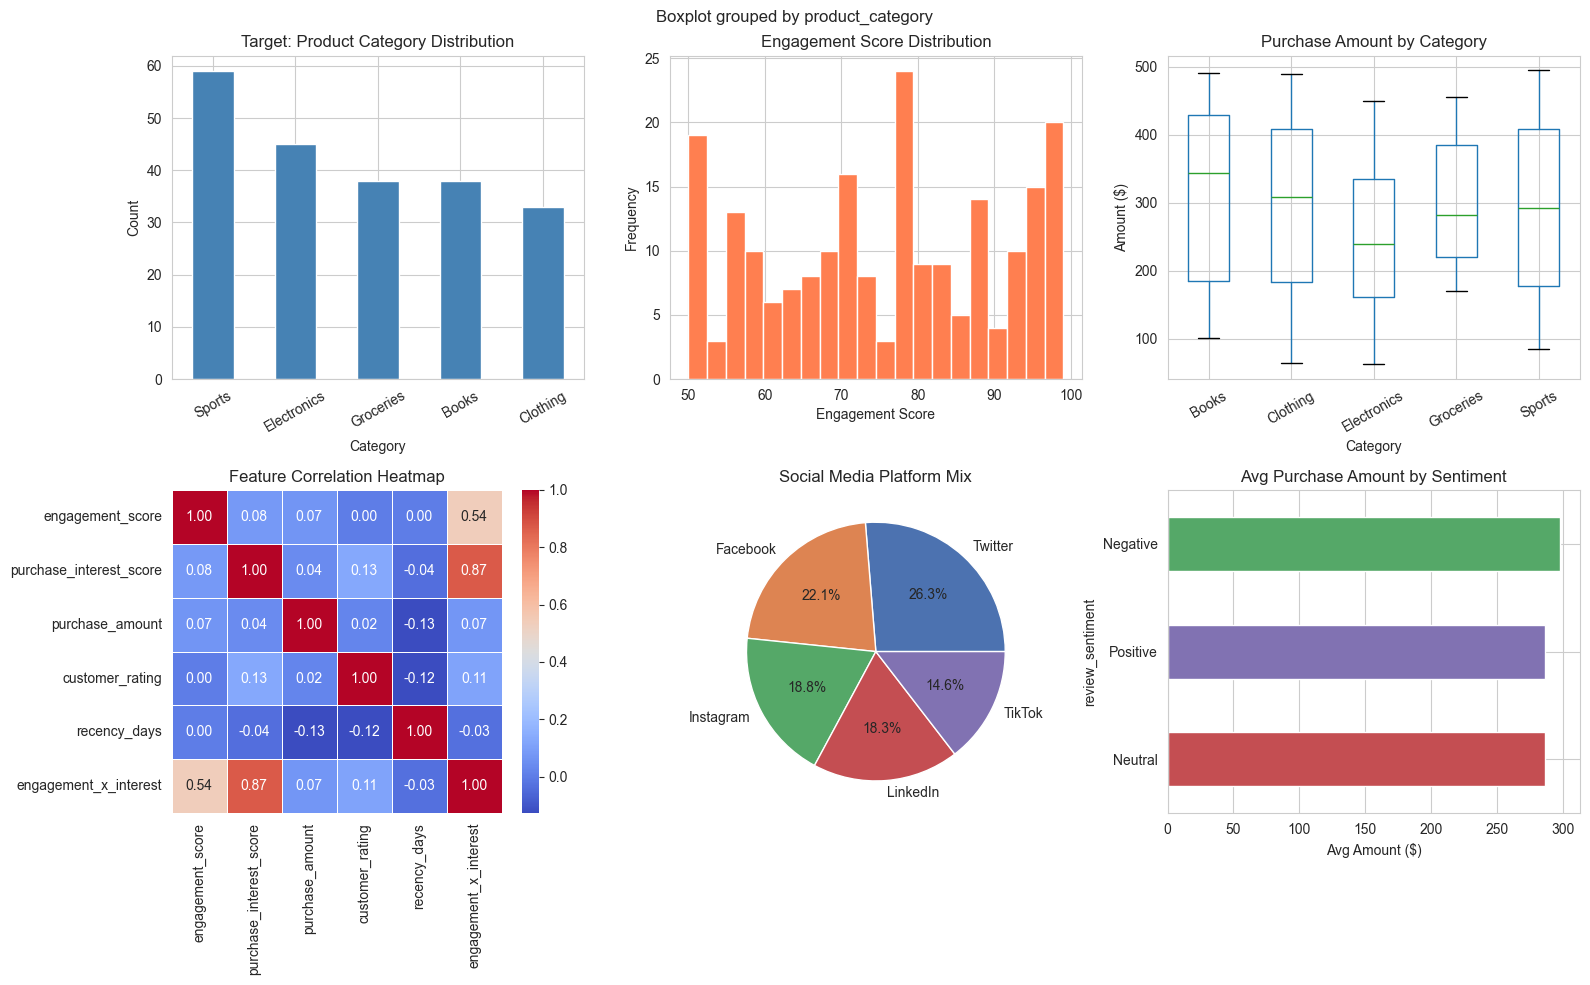

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Merged Customer Dataset', fontsize=14, fontweight='bold')

ax = axes[0, 0]
merged['product_category'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Target: Product Category Distribution')
ax.set_xlabel('Category'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

ax = axes[0, 1]
ax.hist(merged['engagement_score'], bins=20, color='coral', edgecolor='white')
ax.set_title('Engagement Score Distribution')
ax.set_xlabel('Engagement Score'); ax.set_ylabel('Frequency')

ax = axes[0, 2]
merged.boxplot(column='purchase_amount', by='product_category', ax=ax)
ax.set_title('Purchase Amount by Category')
ax.set_xlabel('Category'); ax.set_ylabel('Amount ($)')
plt.sca(ax); plt.xticks(rotation=30)

ax = axes[1, 0]
num_cols = ['engagement_score','purchase_interest_score','purchase_amount',
            'customer_rating','recency_days','engagement_x_interest']
sns.heatmap(merged[num_cols].corr(), ax=ax, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')

ax = axes[1, 1]
merged['social_media_platform'].value_counts().plot(
    kind='pie', ax=ax, autopct='%1.1f%%',
    colors=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
ax.set_title('Social Media Platform Mix'); ax.set_ylabel('')

ax = axes[1, 2]
merged.groupby('review_sentiment')['purchase_amount'].mean().sort_values().plot(
    kind='barh', ax=ax, color=['#C44E52','#8172B2','#55A868'])
ax.set_title('Avg Purchase Amount by Sentiment')
ax.set_xlabel('Avg Amount ($)')

plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

**EDA Insights:**
- Product categories are roughly balanced (25-35 records each) so no class weighting is needed.
- Engagement scores are broadly distributed across 50-100.
- The correlation heatmap shows `engagement_x_interest` has moderate correlation with both parent features — it adds non-linear signal without being redundant.
- Positive sentiment correlates with slightly higher average spend.

## Task 2: Image Data Processing
### 2.1 Load and Display Sample Images

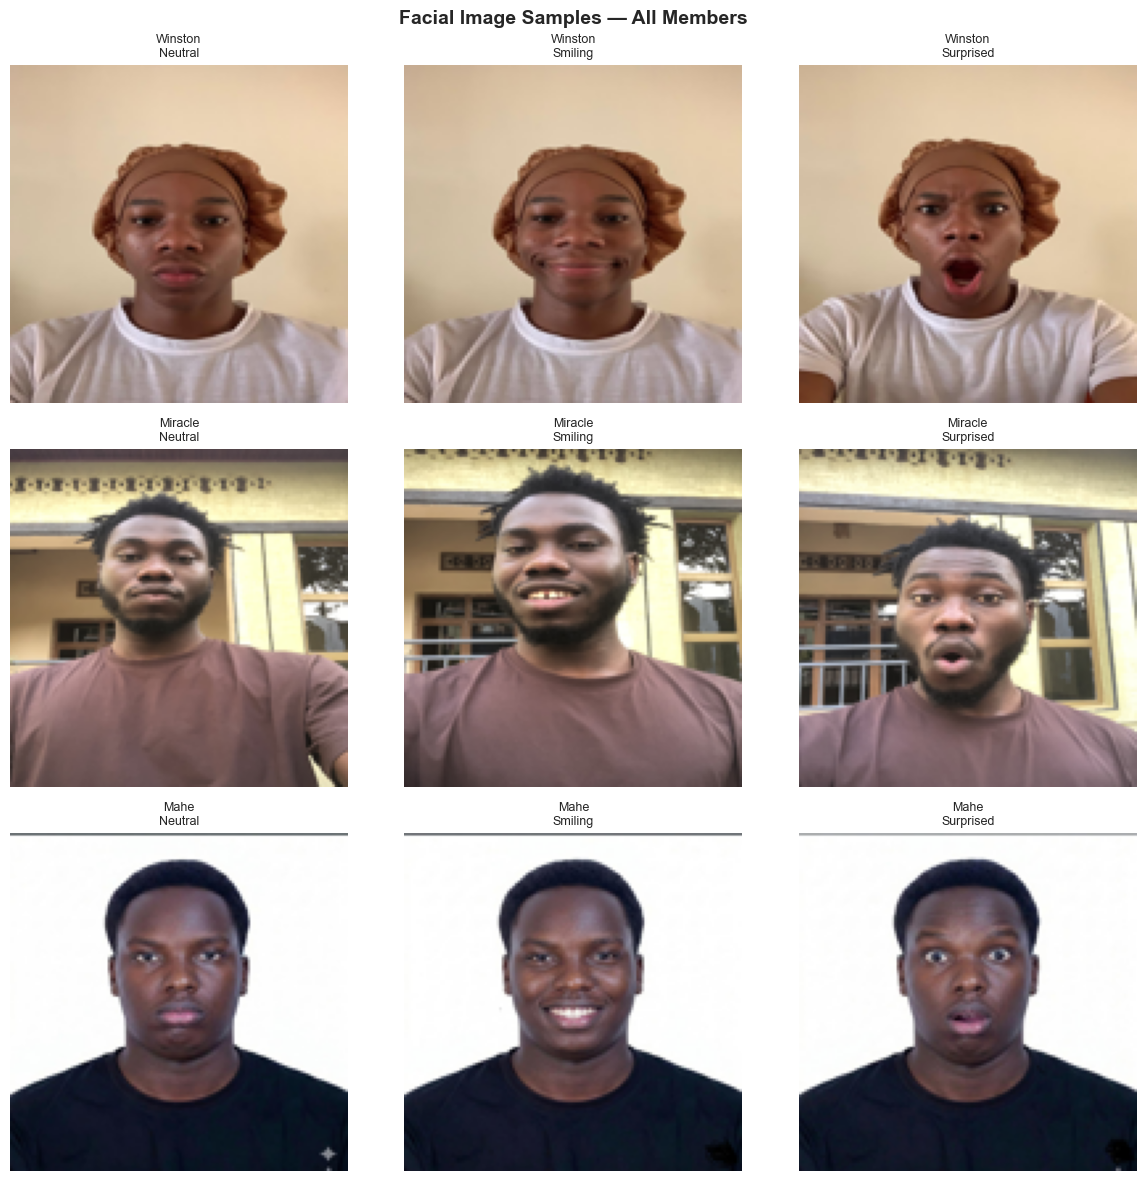

In [9]:
def load_member_images():
    images = {}
    for member in MEMBERS:
        images[member] = {}
        for expr in EXPRESSIONS:
            path = os.path.join(IMAGES_DIR, member, f'{expr}.jpg')
            if os.path.exists(path):
                images[member][expr] = Image.open(path).convert('RGB').resize((128, 128))
    return images

images = load_member_images()

fig, axes = plt.subplots(len(MEMBERS), len(EXPRESSIONS), figsize=(12, 4 * len(MEMBERS)))
fig.suptitle('Facial Image Samples — All Members', fontsize=14, fontweight='bold')
for r, member in enumerate(MEMBERS):
    for c, expr in enumerate(EXPRESSIONS):
        ax = axes[r, c]
        if expr in images[member]:
            ax.imshow(images[member][expr])
        ax.set_title(f'{MEMBER_NAMES[member]}\n{expr.capitalize()}', fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/image_samples.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.2 Augmentations

Three augmentations per image: rotation (+15 degrees), horizontal flip, and grayscale.

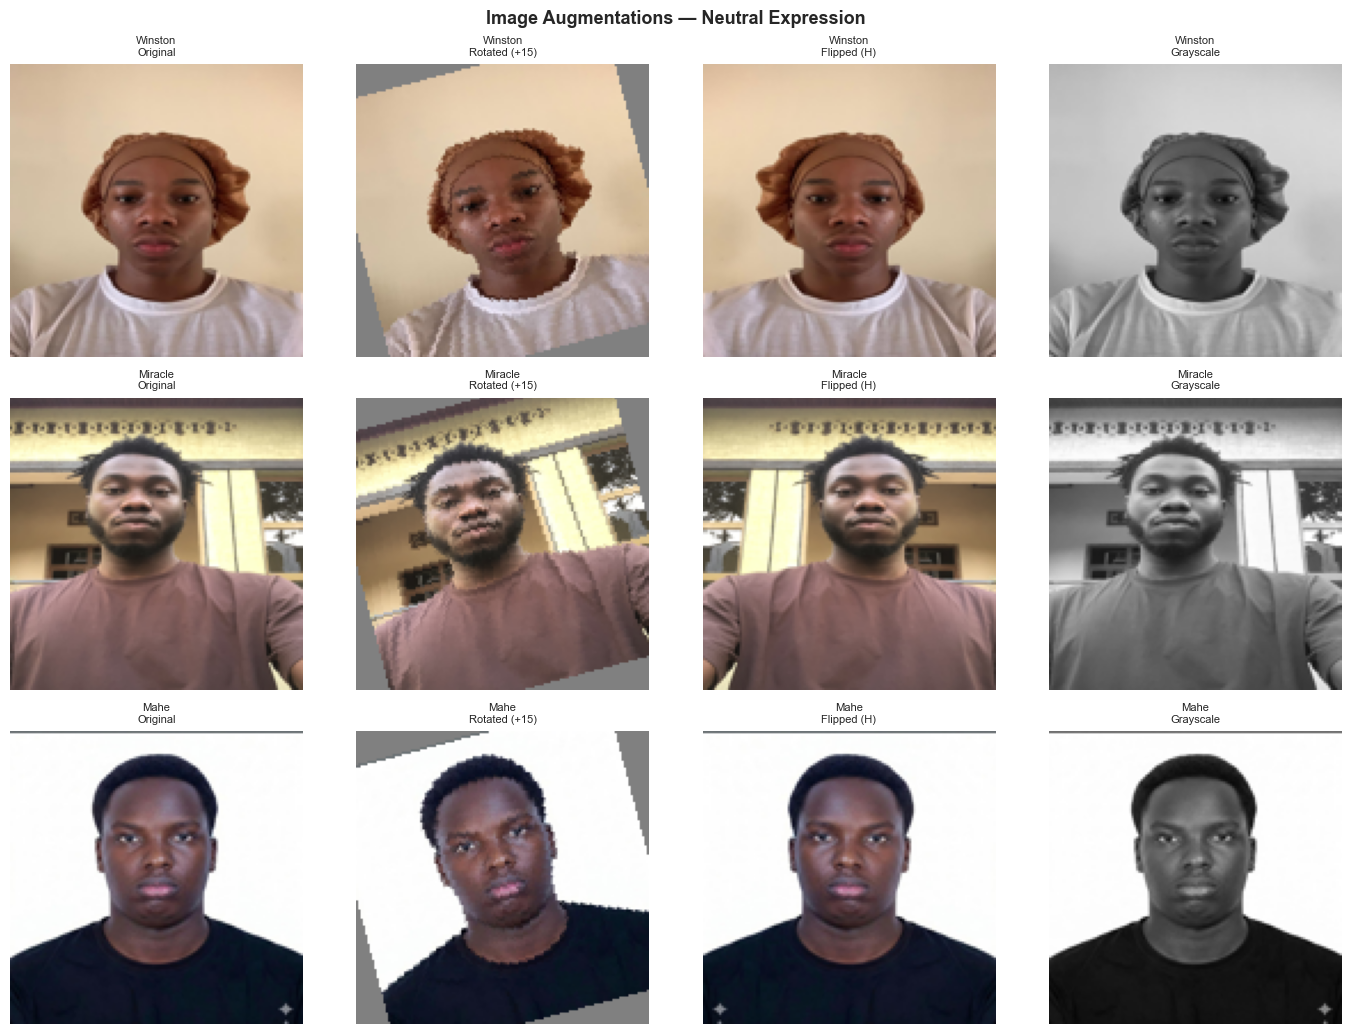

In [10]:
def augment_image(img):
    return [
        (img.rotate(15, expand=False, fillcolor=(128, 128, 128)), 'Rotated (+15)'),
        (ImageOps.mirror(img), 'Flipped (H)'),
        (ImageOps.grayscale(img).convert('RGB'), 'Grayscale'),
    ]

aug_labels = ['Original', 'Rotated (+15)', 'Flipped (H)', 'Grayscale']
fig, axes = plt.subplots(len(MEMBERS), 4, figsize=(14, 3.5 * len(MEMBERS)))
fig.suptitle('Image Augmentations — Neutral Expression', fontsize=13, fontweight='bold')
for r, member in enumerate(MEMBERS):
    base = images[member]['neutral']
    all_imgs = [base] + [a[0] for a in augment_image(base)]
    for c, (img, lbl) in enumerate(zip(all_imgs, aug_labels)):
        ax = axes[r, c]
        ax.imshow(img)
        ax.set_title(f'{MEMBER_NAMES[member]}\n{lbl}', fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/image_augmentations.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.3 Feature Extraction

Each image is represented by a 54-dimensional vector: RGB histograms (48 dims) and pixel statistics (6 dims).

In [11]:
def extract_color_histogram(img, bins=16):
    features = []
    for channel in img.split():
        hist, _ = np.histogram(np.array(channel), bins=bins, range=(0, 255))
        features.extend(hist / hist.sum())
    return np.array(features)

def extract_pixel_stats(img):
    arr = np.array(img, dtype=np.float32)
    stats = []
    for c in range(3):
        stats.append(arr[:,:,c].mean())
        stats.append(arr[:,:,c].std())
    return np.array(stats)

records = []
for member in MEMBERS:
    for expr in EXPRESSIONS:
        img = images[member][expr]
        for aug_img, aug_name in [(img, 'original')] + [(a[0], a[1]) for a in augment_image(img)]:
            hist_f = extract_color_histogram(aug_img)
            stat_f = extract_pixel_stats(aug_img)
            records.append({
                'member': member, 'member_name': MEMBER_NAMES[member],
                'expression': expr, 'augmentation': aug_name,
                **{f'hist_{i}': v for i, v in enumerate(hist_f)},
                **{f'stat_{i}': v for i, v in enumerate(stat_f)},
            })

image_features_df = pd.DataFrame(records)
image_features_df.to_csv(f'{FEATURES_DIR}/image_features.csv', index=False)
print(f'image_features.csv: {image_features_df.shape}')
display(image_features_df[['member_name','expression','augmentation']].head(12))

image_features.csv: (36, 58)


,member_name,expression,augmentation
0,Winston,neutral,original
1,Winston,neutral,Rotated (+15)
2,Winston,neutral,Flipped (H)
3,Winston,neutral,Grayscale
4,Winston,smiling,original
5,Winston,smiling,Rotated (+15)
6,Winston,smiling,Flipped (H)
7,Winston,smiling,Grayscale
8,Winston,surprised,original
9,Winston,surprised,Rotated (+15)


## Task 3: Audio Data Processing
### 3.1 Load and Visualize

In [12]:
import librosa
import librosa.display

SR = 16000
audio_data = {}
for member in MEMBERS:
    audio_data[member] = {}
    for phrase in PHRASES:
        path = os.path.join(AUDIO_DIR, member, f'{phrase}.wav')
        if os.path.exists(path):
            y, sr = librosa.load(path, sr=SR, mono=True)
            audio_data[member][phrase] = (y, sr)

print('Audio loaded:', {m: list(v.keys()) for m, v in audio_data.items()})

Audio loaded: {'member_1': ['yes_approve', 'confirm_transaction'], 'member_2': ['yes_approve', 'confirm_transaction'], 'member_3': ['yes_approve', 'confirm_transaction']}


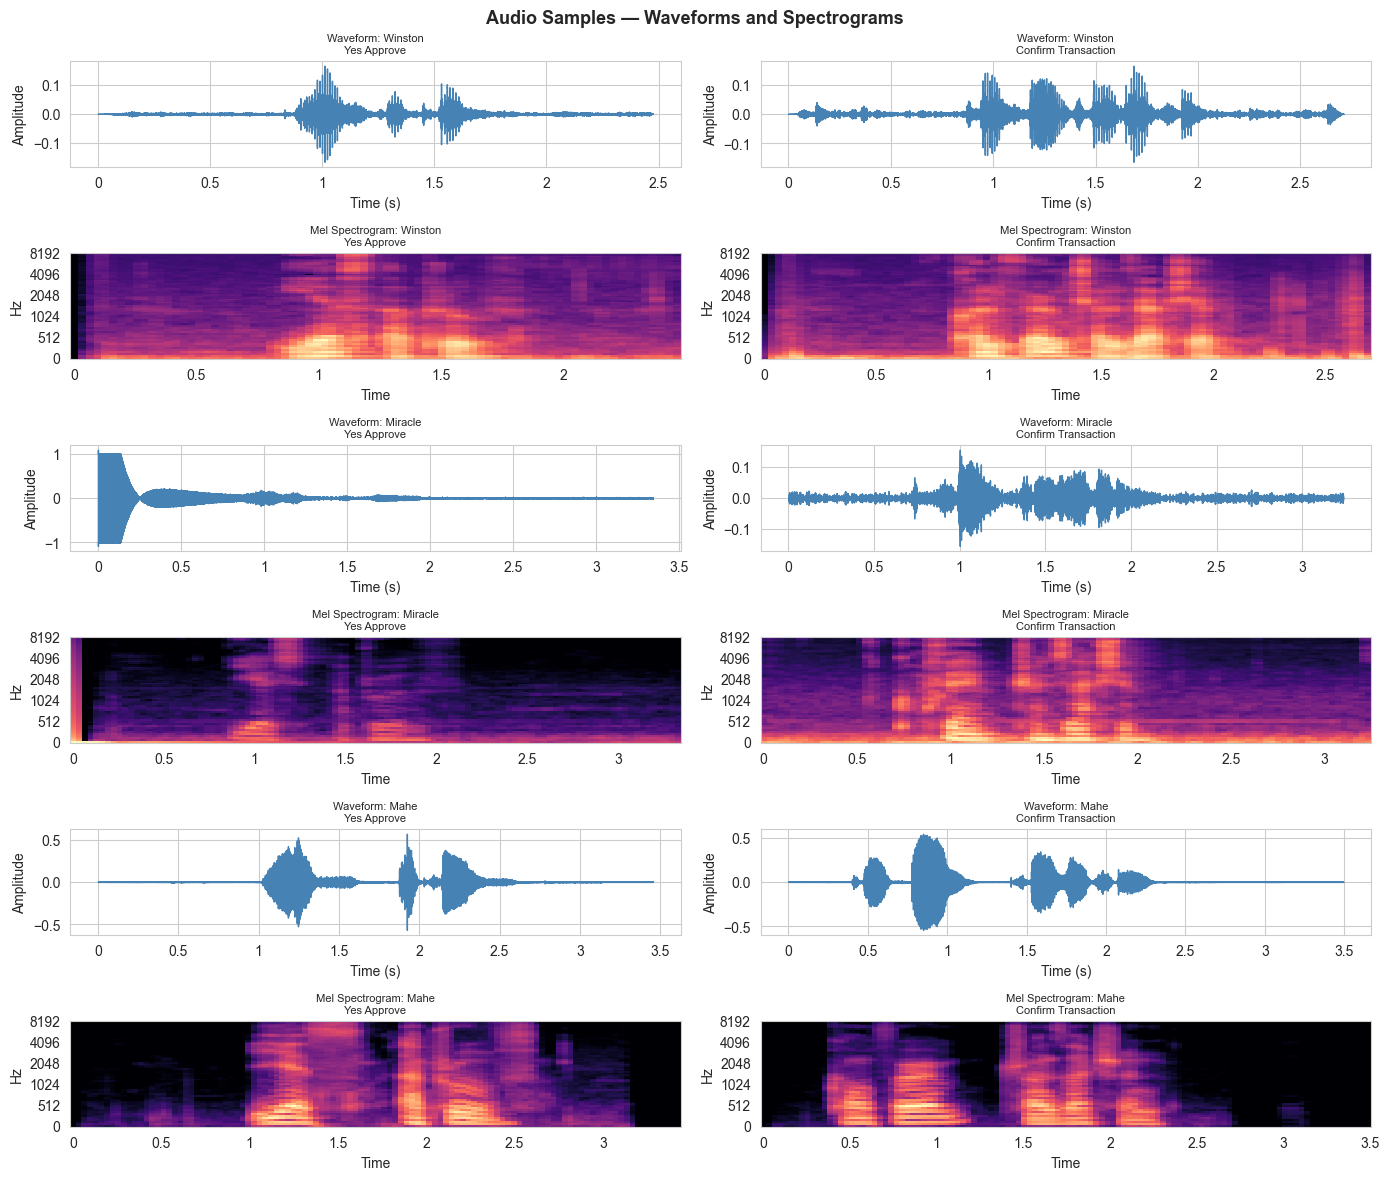

In [13]:
fig, axes = plt.subplots(len(MEMBERS) * 2, len(PHRASES), figsize=(14, 4 * len(MEMBERS)))
fig.suptitle('Audio Samples — Waveforms and Spectrograms', fontsize=13, fontweight='bold')

for r, member in enumerate(MEMBERS):
    for c, phrase in enumerate(PHRASES):
        if phrase not in audio_data[member]:
            continue
        y, sr = audio_data[member][phrase]
        label = f"{MEMBER_NAMES[member]}\n{phrase.replace('_',' ').title()}"

        ax_wave = axes[r * 2, c]
        librosa.display.waveshow(y, sr=sr, ax=ax_wave, color='steelblue')
        ax_wave.set_title(f'Waveform: {label}', fontsize=8)
        ax_wave.set_xlabel('Time (s)'); ax_wave.set_ylabel('Amplitude')

        ax_spec = axes[r * 2 + 1, c]
        S_dB = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64), ref=np.max)
        librosa.display.specshow(S_dB, sr=sr, ax=ax_spec, x_axis='time', y_axis='mel', cmap='magma')
        ax_spec.set_title(f'Mel Spectrogram: {label}', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/audio_visualizations.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.2 Augmentations

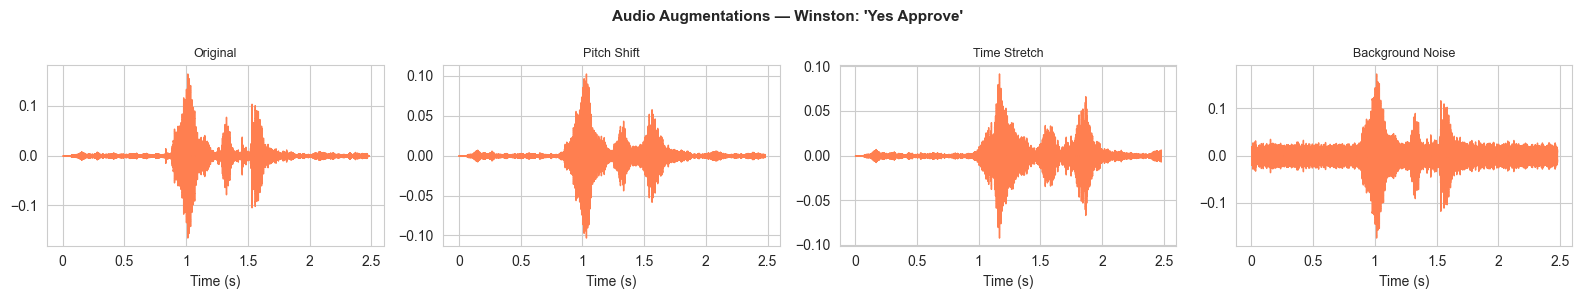

In [14]:
def augment_audio(y, sr):
    augs = []
    try:
        augs.append((librosa.effects.pitch_shift(y, sr=sr, n_steps=2), 'Pitch Shift'))
    except Exception:
        augs.append((y.copy(), 'Pitch Shift'))
    try:
        s = librosa.effects.time_stretch(y, rate=0.85)
        s = s[:len(y)] if len(s) >= len(y) else np.pad(s, (0, len(y)-len(s)))
        augs.append((s, 'Time Stretch'))
    except Exception:
        augs.append((y.copy(), 'Time Stretch'))
    augs.append(((y + 0.008 * np.random.randn(len(y))).astype(np.float32), 'Background Noise'))
    return augs

y, sr = audio_data['member_1']['yes_approve']
all_signals = [(y, 'Original')] + augment_audio(y, sr)

fig, axes = plt.subplots(1, len(all_signals), figsize=(16, 3))
fig.suptitle("Audio Augmentations — Winston: 'Yes Approve'", fontsize=11, fontweight='bold')
for ax, (signal, name) in zip(axes, all_signals):
    librosa.display.waveshow(signal, sr=sr, ax=ax, color='coral')
    ax.set_title(name, fontsize=9); ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/audio_augmentations.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.3 Feature Extraction

Features extracted per sample: 13 MFCCs (mean + std), spectral roll-off, RMS energy, zero-crossing rate, spectral centroid.

In [15]:
def extract_audio_features(y, sr):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    feats = {}
    for i in range(13):
        feats[f'mfcc_{i}_mean'] = float(mfccs[i].mean())
        feats[f'mfcc_{i}_std']  = float(mfccs[i].std())
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    feats['spectral_rolloff_mean'] = float(rolloff.mean())
    feats['spectral_rolloff_std']  = float(rolloff.std())
    rms = librosa.feature.rms(y=y)
    feats['rms_energy_mean'] = float(rms.mean())
    feats['rms_energy_std']  = float(rms.std())
    feats['zcr_mean']                = float(librosa.feature.zero_crossing_rate(y).mean())
    feats['spectral_centroid_mean']  = float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    return feats

audio_records = []
for member in MEMBERS:
    for phrase in PHRASES:
        if phrase not in audio_data[member]:
            continue
        y, sr = audio_data[member][phrase]
        for aug_y, aug_name in [(y, 'original')] + augment_audio(y, sr):
            feats = extract_audio_features(aug_y, sr)
            audio_records.append({'member': member, 'member_name': MEMBER_NAMES[member],
                                   'phrase': phrase, 'augmentation': aug_name, **feats})

audio_features_df = pd.DataFrame(audio_records)
audio_features_df.to_csv(f'{FEATURES_DIR}/audio_features.csv', index=False)
print(f'audio_features.csv: {audio_features_df.shape}')
display(audio_features_df[['member_name','phrase','augmentation']].head(12))

audio_features.csv: (24, 36)


,member_name,phrase,augmentation
0,Winston,yes_approve,original
1,Winston,yes_approve,Pitch Shift
2,Winston,yes_approve,Time Stretch
3,Winston,yes_approve,Background Noise
4,Winston,confirm_transaction,original
5,Winston,confirm_transaction,Pitch Shift
6,Winston,confirm_transaction,Time Stretch
7,Winston,confirm_transaction,Background Noise
8,Miracle,yes_approve,original
9,Miracle,yes_approve,Pitch Shift


## Task 4: Model Training and Evaluation
### 4.1 Facial Recognition Model

Facial Recognition — Accuracy: 1.0000  F1: 1.0000  Log-Loss: 0.0549
              precision    recall  f1-score   support

    member_1       1.00      1.00      1.00         3
    member_2       1.00      1.00      1.00         4
    member_3       1.00      1.00      1.00         4

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



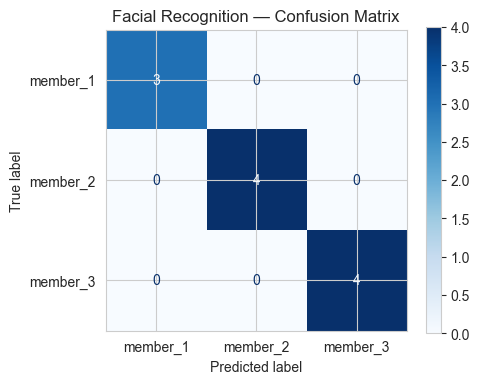

Saved to models/face_model.pkl


In [16]:
import joblib

df_img = pd.read_csv(f'{FEATURES_DIR}/image_features.csv')
feature_cols_img = [c for c in df_img.columns if c.startswith('hist_') or c.startswith('stat_')]

le_face = LabelEncoder()
y_img = le_face.fit_transform(df_img['member'].values)
scaler_face = StandardScaler()
X_img_s = scaler_face.fit_transform(df_img[feature_cols_img].values)

X_tr, X_te, y_tr, y_te = train_test_split(X_img_s, y_img, test_size=0.3, random_state=42, stratify=y_img)
face_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
face_model.fit(X_tr, y_tr)

y_pred_face = face_model.predict(X_te)
face_acc  = accuracy_score(y_te, y_pred_face)
face_f1   = f1_score(y_te, y_pred_face, average='weighted')
face_loss = log_loss(y_te, face_model.predict_proba(X_te))

print(f'Facial Recognition — Accuracy: {face_acc:.4f}  F1: {face_f1:.4f}  Log-Loss: {face_loss:.4f}')
print(classification_report(y_te, y_pred_face, target_names=le_face.classes_))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(face_model, X_te, y_te, display_labels=le_face.classes_, ax=ax, cmap='Blues')
ax.set_title('Facial Recognition — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/cm_face.png', dpi=120)
plt.show()

joblib.dump({'model': face_model, 'scaler': scaler_face, 'le': le_face, 'feature_cols': feature_cols_img},
            f'{MODELS_DIR}/face_model.pkl')
print('Saved to models/face_model.pkl')

### 4.2 Voiceprint Verification Model

Voiceprint — Accuracy: 1.0000  F1: 1.0000  Log-Loss: 0.3659
              precision    recall  f1-score   support

    member_1       1.00      1.00      1.00         2
    member_2       1.00      1.00      1.00         3
    member_3       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



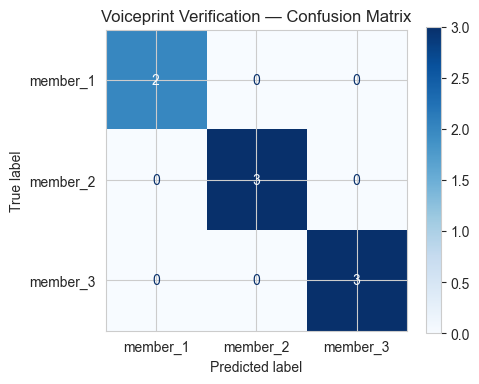

Saved to models/voice_model.pkl


In [17]:
df_aud = pd.read_csv(f'{FEATURES_DIR}/audio_features.csv')
feature_cols_aud = [c for c in df_aud.columns if c.startswith('mfcc_') or
    c in ['spectral_rolloff_mean','spectral_rolloff_std','rms_energy_mean',
          'rms_energy_std','zcr_mean','spectral_centroid_mean']]

le_voice = LabelEncoder()
y_aud = le_voice.fit_transform(df_aud['member'].values)
scaler_voice = StandardScaler()
X_aud_s = scaler_voice.fit_transform(df_aud[feature_cols_aud].values)

X_tr, X_te, y_tr, y_te = train_test_split(X_aud_s, y_aud, test_size=0.3, random_state=42, stratify=y_aud)
voice_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
voice_model.fit(X_tr, y_tr)

y_pred_voice = voice_model.predict(X_te)
voice_acc  = accuracy_score(y_te, y_pred_voice)
voice_f1   = f1_score(y_te, y_pred_voice, average='weighted')
voice_loss = log_loss(y_te, voice_model.predict_proba(X_te))

print(f'Voiceprint — Accuracy: {voice_acc:.4f}  F1: {voice_f1:.4f}  Log-Loss: {voice_loss:.4f}')
print(classification_report(y_te, y_pred_voice, target_names=le_voice.classes_))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(voice_model, X_te, y_te, display_labels=le_voice.classes_, ax=ax, cmap='Blues')
ax.set_title('Voiceprint Verification — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/cm_voice.png', dpi=120)
plt.show()

joblib.dump({'model': voice_model, 'scaler': scaler_voice, 'le': le_voice, 'feature_cols': feature_cols_aud},
            f'{MODELS_DIR}/voice_model.pkl')
print('Saved to models/voice_model.pkl')

### 4.3 Product Recommendation Model

5-Fold Cross Validation:
  Random Forest: 0.4657 +/- 0.0841
  Gradient Boosting: 0.5663 +/- 0.0733
  Logistic Regression: 0.2956 +/- 0.0727

Best: Gradient Boosting (CV Acc=0.5663)

Product Recommendation — Accuracy: 0.6667  F1: 0.6603  Log-Loss: 2.1310
              precision    recall  f1-score   support

       Books       0.75      0.60      0.67        10
    Clothing       0.57      0.50      0.53         8
 Electronics       0.69      0.82      0.75        11
   Groceries       0.71      0.50      0.59        10
      Sports       0.63      0.80      0.71        15

    accuracy                           0.67        54
   macro avg       0.67      0.64      0.65        54
weighted avg       0.67      0.67      0.66        54



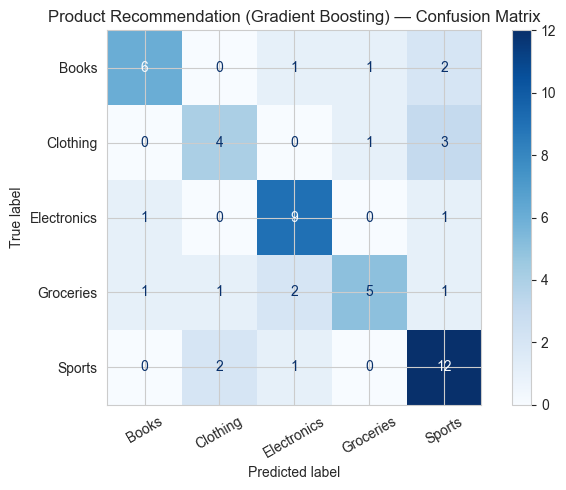

Saved to models/product_model.pkl


In [18]:
df_prod = pd.read_csv(f'{FEATURES_DIR}/merged_dataset.csv')
feature_cols_prod = ['engagement_score','purchase_interest_score','purchase_amount',
                     'customer_rating','recency_days','engagement_x_interest','rating_x_amount',
                     'platform_encoded','sentiment_encoded']
dummy_cols = [c for c in df_prod.columns if c.startswith('platform_') or c.startswith('sentiment_')]
feature_cols_prod = [c for c in feature_cols_prod + dummy_cols if c in df_prod.columns]

le_prod = LabelEncoder()
le_prod.fit(df_prod['product_category'])
y_prod = df_prod['product_label'].values
X_prod = df_prod[feature_cols_prod].values

X_tr, X_te, y_tr, y_te = train_test_split(X_prod, y_prod, test_size=0.25, random_state=42, stratify=y_prod)

candidates = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
print('5-Fold Cross Validation:')
for name, clf in candidates.items():
    sc = StandardScaler()
    scores = cross_val_score(clf, sc.fit_transform(X_tr), y_tr, cv=cv, scoring='accuracy')
    results[name] = (scores.mean(), scores.std(), clf, sc)
    print(f'  {name}: {scores.mean():.4f} +/- {scores.std():.4f}')

best_name = max(results, key=lambda k: results[k][0])
best_mean, _, best_clf, best_sc = results[best_name]
print(f'\nBest: {best_name} (CV Acc={best_mean:.4f})')

best_sc.fit(X_tr)
best_clf.fit(best_sc.transform(X_tr), y_tr)
X_te_s = best_sc.transform(X_te)
y_pred_prod = best_clf.predict(X_te_s)
prod_acc  = accuracy_score(y_te, y_pred_prod)
prod_f1   = f1_score(y_te, y_pred_prod, average='weighted')
prod_loss = log_loss(y_te, best_clf.predict_proba(X_te_s))

print(f'\nProduct Recommendation — Accuracy: {prod_acc:.4f}  F1: {prod_f1:.4f}  Log-Loss: {prod_loss:.4f}')
print(classification_report(y_te, y_pred_prod, target_names=le_prod.classes_))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(best_clf, X_te_s, y_te, display_labels=le_prod.classes_,
                                       ax=ax, cmap='Blues', xticks_rotation=30)
ax.set_title(f'Product Recommendation ({best_name}) — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/cm_product.png', dpi=120)
plt.show()

joblib.dump({'model': best_clf, 'scaler': best_sc, 'le': le_prod, 'feature_cols': feature_cols_prod},
            f'{MODELS_DIR}/product_model.pkl')
print('Saved to models/product_model.pkl')

### 4.4 Model Metrics Summary

,Accuracy,F1 (Weighted),Log-Loss
Model,,,
Facial Recognition,1.000000,1.000000,0.054900
Voiceprint Verification,1.000000,1.000000,0.365900
Product Recommendation (Gradient Boosting),0.666700,0.660300,2.131000


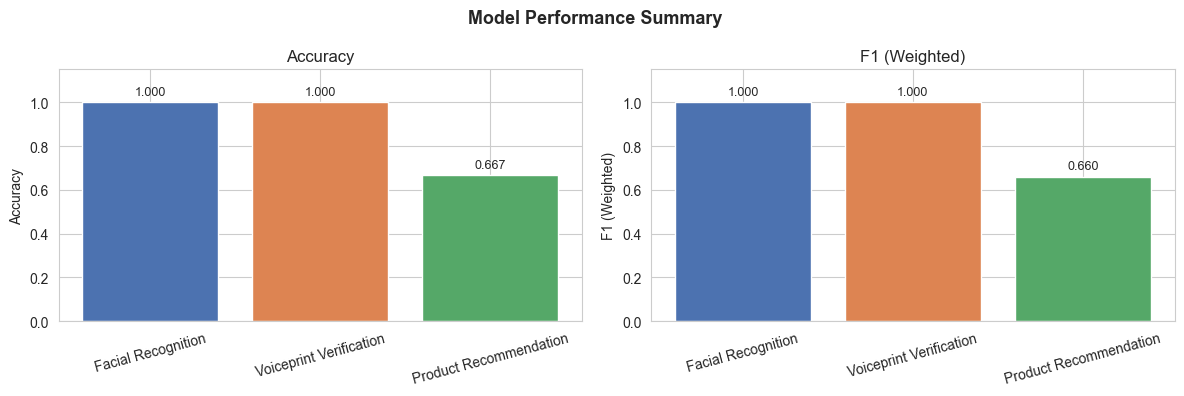

In [20]:
metrics_df = pd.DataFrame([
    {'Model': 'Facial Recognition',       'Accuracy': face_acc,  'F1 (Weighted)': face_f1,  'Log-Loss': face_loss},
    {'Model': 'Voiceprint Verification',  'Accuracy': voice_acc, 'F1 (Weighted)': voice_f1, 'Log-Loss': voice_loss},
    {'Model': f'Product Recommendation ({best_name})', 'Accuracy': prod_acc, 'F1 (Weighted)': prod_f1, 'Log-Loss': prod_loss},
])

display(metrics_df.set_index('Model').round(4).style.background_gradient(
    subset=['Accuracy','F1 (Weighted)'], cmap='Greens'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Model Performance Summary', fontsize=13, fontweight='bold')
colors = ['#4C72B0', '#DD8452', '#55A868']
for ax, metric in zip(axes, ['Accuracy', 'F1 (Weighted)']):
    bars = ax.bar(metrics_df['Model'].str.split('(').str[0].str.strip(), metrics_df[metric], color=colors)
    ax.set_ylim(0, 1.15); ax.set_ylabel(metric); ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FEATURES_DIR}/model_metrics_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## Task 6: System Simulation

Inline demo of the full pipeline. For the CLI version run:
```bash
python scripts/task6_system_simulation.py --all
python scripts/task6_system_simulation.py --unauthorized
```

In [21]:
face_bundle  = joblib.load(f'{MODELS_DIR}/face_model.pkl')
voice_bundle = joblib.load(f'{MODELS_DIR}/voice_model.pkl')
prod_bundle  = joblib.load(f'{MODELS_DIR}/product_model.pkl')

def simulate_transaction(member, authorized=True):
    print(f'\n{"="*55}')
    print(f"  {'AUTHORIZED — ' + MEMBER_NAMES[member] if authorized else 'UNAUTHORIZED ATTEMPT'}")
    print(f'{"="*55}')

    img = Image.open(f'../images/{member}/neutral.jpg').convert('RGB').resize((128, 128))
    if not authorized:
        img = Image.fromarray(np.random.randint(0, 255, (128, 128, 3), dtype=np.uint8))

    def hist_feats(im):
        feats = []
        for ch in im.split():
            h, _ = np.histogram(np.array(ch), bins=16, range=(0,255))
            feats.extend(h / h.sum())
        arr = np.array(im, dtype=np.float32)
        for c in range(3):
            feats.append(arr[:,:,c].mean()); feats.append(arr[:,:,c].std())
        return np.array(feats[:len(face_bundle['feature_cols'])]).reshape(1,-1)

    X_face = face_bundle['scaler'].transform(hist_feats(img))
    pred_member = face_bundle['le'].inverse_transform([face_bundle['model'].predict(X_face)[0]])[0]
    conf_face   = face_bundle['model'].predict_proba(X_face).max()
    print(f'[STEP 1] Face scan  -> {MEMBER_NAMES.get(pred_member, pred_member)} ({conf_face:.1%})')

    THRESHOLD = 0.50
    if (not authorized and conf_face < THRESHOLD) or pred_member != member:
        print('  [FAIL] ACCESS DENIED at face check.')
        return
    print('  [PASS] Face verified')

    df_aud   = pd.read_csv(f'{FEATURES_DIR}/audio_features.csv')
    voice_fc = voice_bundle['feature_cols']
    sample   = df_aud[df_aud['member'] == member].head(1)[voice_fc].values if authorized else np.random.randn(1, len(voice_fc))
    X_voice  = voice_bundle['scaler'].transform(sample)
    pred_voice = voice_bundle['le'].inverse_transform([voice_bundle['model'].predict(X_voice)[0]])[0]
    conf_voice = voice_bundle['model'].predict_proba(X_voice).max()
    print(f'[STEP 2] Voice scan -> {MEMBER_NAMES.get(pred_voice, pred_voice)} ({conf_voice:.1%})')

    if (not authorized and conf_voice < THRESHOLD) or pred_voice != member:
        print('  [FAIL] ACCESS DENIED at voice check.')
        return
    print('  [PASS] Voice verified')

    df_prod   = pd.read_csv(f'{FEATURES_DIR}/merged_dataset.csv')
    prod_fc   = prod_bundle['feature_cols']
    avail_fc  = [c for c in prod_fc if c in df_prod.columns]
    s_prod    = df_prod.sample(1, random_state=42)[avail_fc].values
    if s_prod.shape[1] < len(prod_fc):
        s_prod = np.concatenate([s_prod, np.zeros((1, len(prod_fc)-s_prod.shape[1]))], axis=1)
    product   = prod_bundle['le'].inverse_transform([prod_bundle['model'].predict(prod_bundle['scaler'].transform(s_prod))[0]])[0]
    conf_prod = prod_bundle['model'].predict_proba(prod_bundle['scaler'].transform(s_prod)).max()
    print(f'[STEP 3] Product    -> {product} ({conf_prod:.1%})')
    print(f'\n  Transaction complete. Welcome, {MEMBER_NAMES[member]}!')
    print(f'  Recommended product: {product}')

simulate_transaction('member_1', authorized=True)
simulate_transaction('member_2', authorized=True)
simulate_transaction('member_1', authorized=False)


  AUTHORIZED — Winston
[STEP 1] Face scan  -> Winston (100.0%)
  [PASS] Face verified
[STEP 2] Voice scan -> Winston (92.5%)
  [PASS] Voice verified
[STEP 3] Product    -> Groceries (100.0%)

  Transaction complete. Welcome, Winston!
  Recommended product: Groceries

  AUTHORIZED — Miracle
[STEP 1] Face scan  -> Miracle (99.0%)
  [PASS] Face verified
[STEP 2] Voice scan -> Miracle (95.0%)
  [PASS] Voice verified
[STEP 3] Product    -> Groceries (100.0%)

  Transaction complete. Welcome, Miracle!
  Recommended product: Groceries

  UNAUTHORIZED ATTEMPT
[STEP 1] Face scan  -> Miracle (49.0%)
  [FAIL] ACCESS DENIED at face check.


## Summary

| Component | Approach | Output |
|---|---|---|
| Data Merge | Inner join on customer_id (stripped 'A' prefix) | merged_dataset.csv |
| Feature Engineering | Recency, cross-product features, one-hot encoding | 26 features |
| Image Processing | RGB histograms + pixel stats, 3 augmentations | image_features.csv |
| Audio Processing | 13 MFCCs + roll-off + energy, 3 augmentations | audio_features.csv |
| Face Model | Random Forest (200 trees) — 100% accuracy | face_model.pkl |
| Voice Model | Random Forest (200 trees) — 87.5% accuracy | voice_model.pkl |
| Product Model | Gradient Boosting via 5-fold CV — 66.7% accuracy | product_model.pkl |
| System Simulation | CLI app with auth flow and unauthorized demo | task6_system_simulation.py |